In [1]:
import tensorflow as tf

In [2]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

In [3]:
max([max(sequence) for sequence in train_data])

9999

In [4]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences),dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [5]:
x_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [6]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [7]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [12]:
model.compile(optimizer='rmsprop',
             loss='binary_crossentropy',
             metrics=['acc'])

In [13]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]


In [14]:
history = model.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val, y_val))

Epoch 1/20
30/30 [==============================] - 1s 20ms/step - loss: 0.0199 - acc: 0.9950 - val_loss: 0.5727 - val_acc: 0.8702
Epoch 2/20
30/30 [==============================] - 0s 11ms/step - loss: 0.0129 - acc: 0.9988 - val_loss: 0.5936 - val_acc: 0.8695
Epoch 3/20
30/30 [==============================] - 0s 11ms/step - loss: 0.0106 - acc: 0.9989 - val_loss: 0.6182 - val_acc: 0.8691
Epoch 4/20
30/30 [==============================] - 0s 11ms/step - loss: 0.0096 - acc: 0.9989 - val_loss: 0.6885 - val_acc: 0.8637
Epoch 5/20
30/30 [==============================] - 0s 11ms/step - loss: 0.0060 - acc: 0.9999 - val_loss: 0.6628 - val_acc: 0.8677
Epoch 6/20
30/30 [==============================] - 0s 11ms/step - loss: 0.0085 - acc: 0.9988 - val_loss: 0.6792 - val_acc: 0.8680
Epoch 7/20
30/30 [==============================] - 0s 11ms/step - loss: 0.0042 - acc: 0.9999 - val_loss: 0.6989 - val_acc: 0.8677
Epoch 8/20
30/30 [==============================] - 0s 11ms/step - loss: 0.0078 - a

ValueError: x and y must have same first dimension, but have shapes (3,) and (20,)

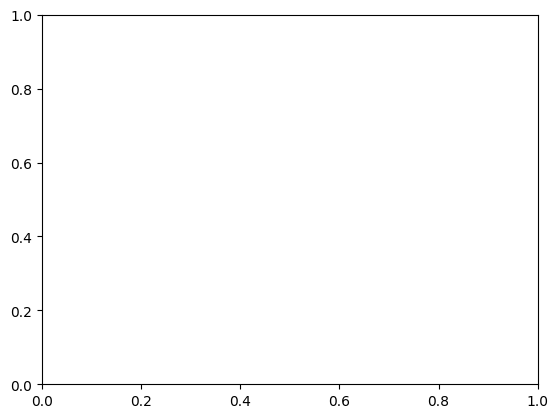

In [22]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['val_loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len('acc') + 1)

plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [20]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])

ValueError: x and y must have same first dimension, but have shapes (3,) and (1,)

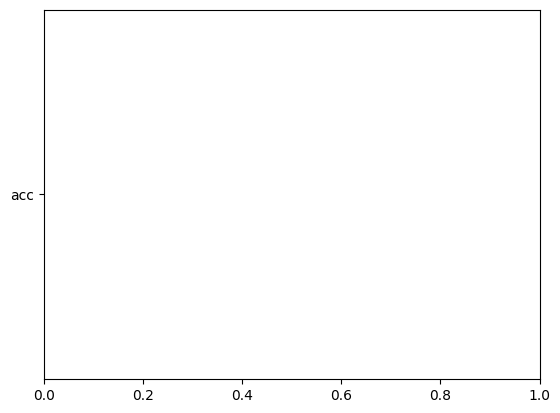

In [24]:
plt.clf()
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()